# CNN Drawing Recognition - Jonah
TU-Berlin Hand Sketch dataset (250 classes, ~80 images per class)

## 1 - Imports

In [48]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2 - Mount Drive and unzip dataset

In [49]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Classes/Computer vision/Final-data/archive.zip"
dataset_root = "/content/TUBerlin/png_ready"

if not os.path.exists(dataset_root):
    !unzip -q "$zip_path" -d /content/

print("Path exists:", os.path.exists(dataset_root))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path exists: True


## 3 - Hyperparameters

In [ ]:
img_size = 96
batch_size = 64
learning_rate = 3e-4 # 1e-3 was too high
num_epochs = 100

random_seed = 42
torch.manual_seed(random_seed)
random.seed(random_seed)
np.random.seed(random_seed)

## 4 - Transforms

In [51]:
# Sketches are line drawings -> grayscale, 1 channel
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.RandomAffine(degrees=10, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# No augmentation for val/test
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## 5 - Load dataset and split into train / val

In [ ]:
full_dataset = torchvision.datasets.ImageFolder(root=dataset_root, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

# 80/20 train/val split
n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

trainset, valset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(random_seed)
)

eval_base = copy.deepcopy(full_dataset)
eval_base.transform = eval_transform
valset.dataset = eval_base

print(f"Train: {len(trainset)}, Val: {len(valset)}")

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

Train: 16000, Val: 4000


## 6 - Preview some training images

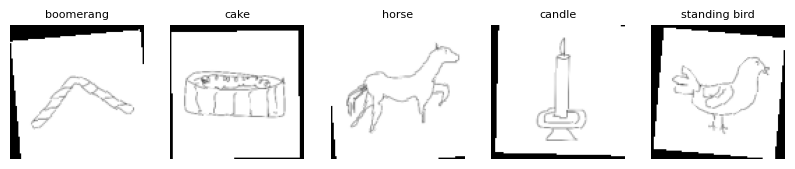

In [53]:
def preview_images(loader, classes, n=5):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(10, 3))
    for i, ax in enumerate(axes):
        img = images[i].squeeze().numpy() * 0.5 + 0.5  # un-normalize
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[i].item()], fontsize=8)
        ax.axis('off')
    plt.show()

preview_images(train_loader, class_names)

## 7 - Define CNN class

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        # Wider channels than baseline (64->128->256->512) -> more feature capacity per resolution
        # Conv -> BN -> ReLU -> MaxPool block pattern
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.3)

        # Global Average Pooling collapses (512, 6, 6) -> (512,)
        # Avoids a giant Flatten+Linear -> fewer params, less overfit
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x)))) # 96 -> 48
        x = self.pool(torch.relu(self.bn2(self.conv2(x)))) # 48 -> 24
        x = self.pool(torch.relu(self.bn3(self.conv3(x)))) # 24 -> 12
        x = self.pool(torch.relu(self.bn4(self.conv4(x)))) # 12 -> 6

        x = self.gap(x) # (N, 512, 6, 6) -> (N, 512, 1, 1)
        x = torch.flatten(x, 1) # -> (N, 512)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 8 - Loss, optimizer, scheduler

In [ ]:
model = CNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

## 9 - Train model

In [56]:
def train_model(model, train_loader, val_loader, epochs):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # Track best val weights so a noisy final epoch doesn't ruin the run
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # training step
        model.train()
        running_loss = 0.0
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # validation step
        model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct / total

        scheduler.step(avg_val_loss)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Save best weights based on lowest val loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Restore best weights for final evaluation
    model.load_state_dict(best_weights)
    return train_losses, val_losses, train_accs, val_accs


train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader, epochs=num_epochs)
print("Finished training - best validation weights restored")

Epoch 1/100, Train Loss: 5.4077, Train Acc: 0.96%, Val Loss: 5.1270, Val Acc: 2.73%
Epoch 2/100, Train Loss: 4.8990, Train Acc: 3.36%, Val Loss: 4.6328, Val Acc: 4.88%
Epoch 3/100, Train Loss: 4.5128, Train Acc: 5.62%, Val Loss: 4.4234, Val Acc: 7.03%
Epoch 4/100, Train Loss: 4.2974, Train Acc: 6.96%, Val Loss: 4.1898, Val Acc: 8.47%
Epoch 5/100, Train Loss: 4.0957, Train Acc: 9.85%, Val Loss: 4.3057, Val Acc: 9.45%
Epoch 6/100, Train Loss: 3.9475, Train Acc: 11.89%, Val Loss: 4.1109, Val Acc: 10.62%
Epoch 7/100, Train Loss: 3.8115, Train Acc: 13.49%, Val Loss: 3.8452, Val Acc: 14.30%
Epoch 8/100, Train Loss: 3.7135, Train Acc: 15.08%, Val Loss: 4.1106, Val Acc: 10.05%
Epoch 9/100, Train Loss: 3.6286, Train Acc: 16.39%, Val Loss: 4.0887, Val Acc: 11.75%
Epoch 10/100, Train Loss: 3.5350, Train Acc: 18.19%, Val Loss: 4.1392, Val Acc: 12.28%
Epoch 11/100, Train Loss: 3.4611, Train Acc: 19.29%, Val Loss: 3.7850, Val Acc: 14.62%
Epoch 12/100, Train Loss: 3.3744, Train Acc: 20.81%, Val Loss:

## 10 - Final evaluation on validation set

In [57]:
def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

evaluate_model(model, val_loader)

Validation Accuracy: 52.98%


## 11 - Plot loss and accuracy curves

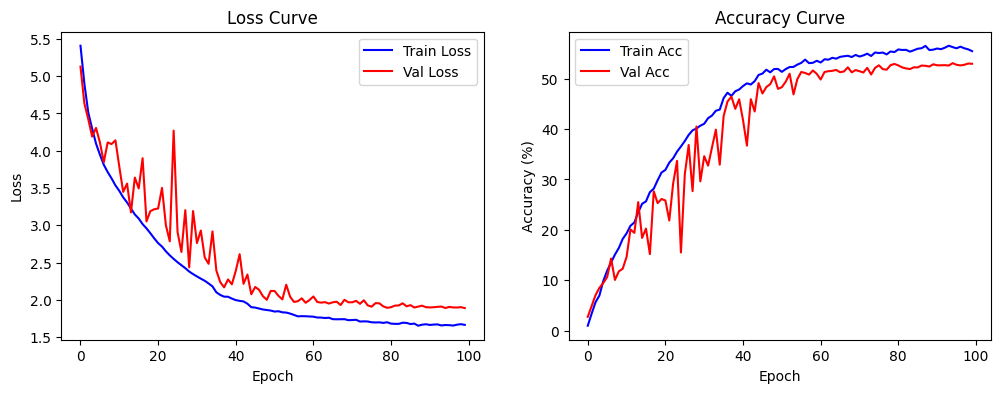

In [58]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

## 12 - Show predictions on validation set

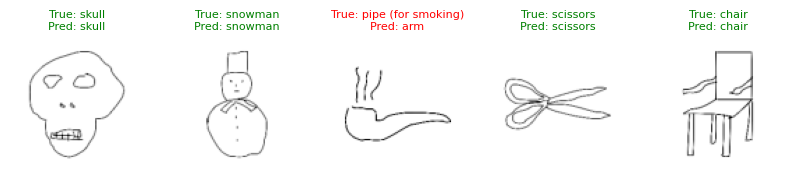

In [59]:
def show_predictions(model, loader, classes, num_samples=5):
    model.eval()
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(1, num_samples, figsize=(10, 5))
    for i, ax in enumerate(axes):
        img = images[i].squeeze().numpy() * 0.5 + 0.5

        with torch.no_grad():
            outputs = model(images[i:i+1].to(device))
            predicted_label = torch.argmax(outputs, 1).item()

        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {classes[labels[i].item()]}\nPred: {classes[predicted_label]}",
                     color='green' if predicted_label == labels[i].item() else 'red',
                     fontsize=8)
        ax.axis('off')
    plt.show()

show_predictions(model, val_loader, class_names)

## 13 - Save model

In [60]:
save_path = "/content/drive/MyDrive/Classes/Computer vision/Final-data/sketch_cnn_jonah.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/Classes/Computer vision/Final-data/sketch_cnn_jonah.pth
